# EDA — Analyse Exploratoire des Données

**Objectif :** Comprendre la structure et les patterns de l'empreinte environnementale alimentaire mondiale,  
tester les hypothèses H1/H2 et sélectionner les variables pour le ML.

**Source principale :** Table `fait_impact_pays_annee` (Data Warehouse PostgreSQL)

**Hypothèses à tester :**
- H1 : Les pays riches (PIB/hab élevé) ont une empreinte animale plus forte
- H2 : L'urbanisation croissante est corrélée à une consommation de viande plus élevée

## 3.1 — Connexion & helpers

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Style global
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

# Connexion PostgreSQL
load_dotenv('../.env')
PG_HOST = os.getenv('POSTGRES_HOST', 'localhost')
PG_PORT = os.getenv('POSTGRES_PORT', '5432')
PG_DB   = os.getenv('POSTGRES_DB',   'food_impact')
PG_USER = os.getenv('POSTGRES_USER', 'food_user')
PG_PASS = os.getenv('POSTGRES_PASSWORD', 'food_pass')

DB_URL = f"postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"
engine = create_engine(DB_URL, echo=False)

def query_df(sql):
    return pd.read_sql(text(sql), engine)

# Test connexion
df_test = query_df("SELECT COUNT(*) AS n FROM fait_impact_pays_annee")
print(f"Connexion OK — fait_impact_pays_annee : {df_test['n'].iloc[0]:,} lignes")

Connexion OK — fait_impact_pays_annee : 973,227 lignes


## 3.2 — Chargement des données

In [2]:
# Table ML principale enrichie avec dimensions
df = query_df("""
    SELECT
        f.pays_id,
        f.annee_id,
        f.produit_id,
        f.quantite_1000t,
        f.co2_total_kg,
        f.freshwater_total_litres,
        f.land_use_total_m2,
        p.nom_pays,
        p.region,
        p.code_iso3 AS iso3,
        t.annee,
        t.decennie,
        pr.categorie,
        pr.nom_fao AS item_fao,
        s.pib_per_capita,
        s.taux_urbanisation,
        s.population,
        s.surface_agricole
    FROM fait_impact_pays_annee f
    JOIN dim_pays p      ON f.pays_id    = p.pays_id
    JOIN dim_temps t     ON f.annee_id   = t.annee_id
    JOIN dim_produits pr ON f.produit_id = pr.produit_id
    LEFT JOIN dim_socio_economique s
           ON f.pays_id = s.pays_id AND f.annee_id = s.annee_id
    WHERE f.co2_total_kg IS NOT NULL
      AND f.quantite_1000t > 0
"""
)

print(f"Dataset : {len(df):,} lignes × {df.shape[1]} colonnes")
df.head(3)

Dataset : 423,337 lignes × 18 colonnes


,pays_id,annee_id,produit_id,quantite_1000t,co2_total_kg,freshwater_total_litres,land_use_total_m2,nom_pays,region,iso3,annee,decennie,categorie,item_fao,pib_per_capita,taux_urbanisation,population,surface_agricole
0,1,1,3,20.0,16000000.0,2.290000e+09,38600000.0,Afghanistan,Africa,AFG,1961,1960,Other,Animal fats,NaN,8.389595,9214083.0,57.878356
1,4,10,90,16.0,17600000.0,NaN,NaN,Angola,Africa,AGO,1970,1970,Cereals,Rice (Milled Equivalent),NaN,14.489036,5852788.0,36.259726
2,4,10,93,1.0,3700000.0,2.377000e+08,10630000.0,Angola,Africa,AGO,1970,1970,Oils & Fats,Sesame seed,NaN,14.489036,5852788.0,36.259726


In [3]:
print("=== Types & valeurs manquantes ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
info_df = pd.DataFrame({'dtype': df.dtypes, 'missing': missing, 'missing_%': missing_pct})
print(info_df[info_df['missing'] > 0])
print(f"\nPériode : {df['annee'].min()} — {df['annee'].max()}")
print(f"Pays : {df['nom_pays'].nunique()}")
print(f"Régions : {df['region'].unique().tolist()}")
print(f"Catégories produits : {df['categorie'].unique().tolist()}")

=== Types & valeurs manquantes ===
                           dtype  missing  missing_%
freshwater_total_litres  float64    33826        8.0
land_use_total_m2        float64    33826        8.0
region                    object     9652        2.3
pib_per_capita           float64    40325        9.5
taux_urbanisation        float64    17000        4.0
population               float64    17000        4.0
surface_agricole         float64    19066        4.5

Période : 1961 — 2023
Pays : 172
Régions : ['Africa', 'Americas', 'Asia', 'Oceania', 'Europe', None]
Catégories produits : ['Other', 'Cereals', 'Oils & Fats', 'Roots & Tubers', 'Vegetables', 'Nuts', 'Alcohol', 'Fruits', 'Legumes', 'Meat', 'Beverages & Stimulants', 'Eggs', 'Fish & Seafood', 'Spices', 'Sugar']


## 3.3 — Analyse univariée

C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\262262828.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Emeline\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


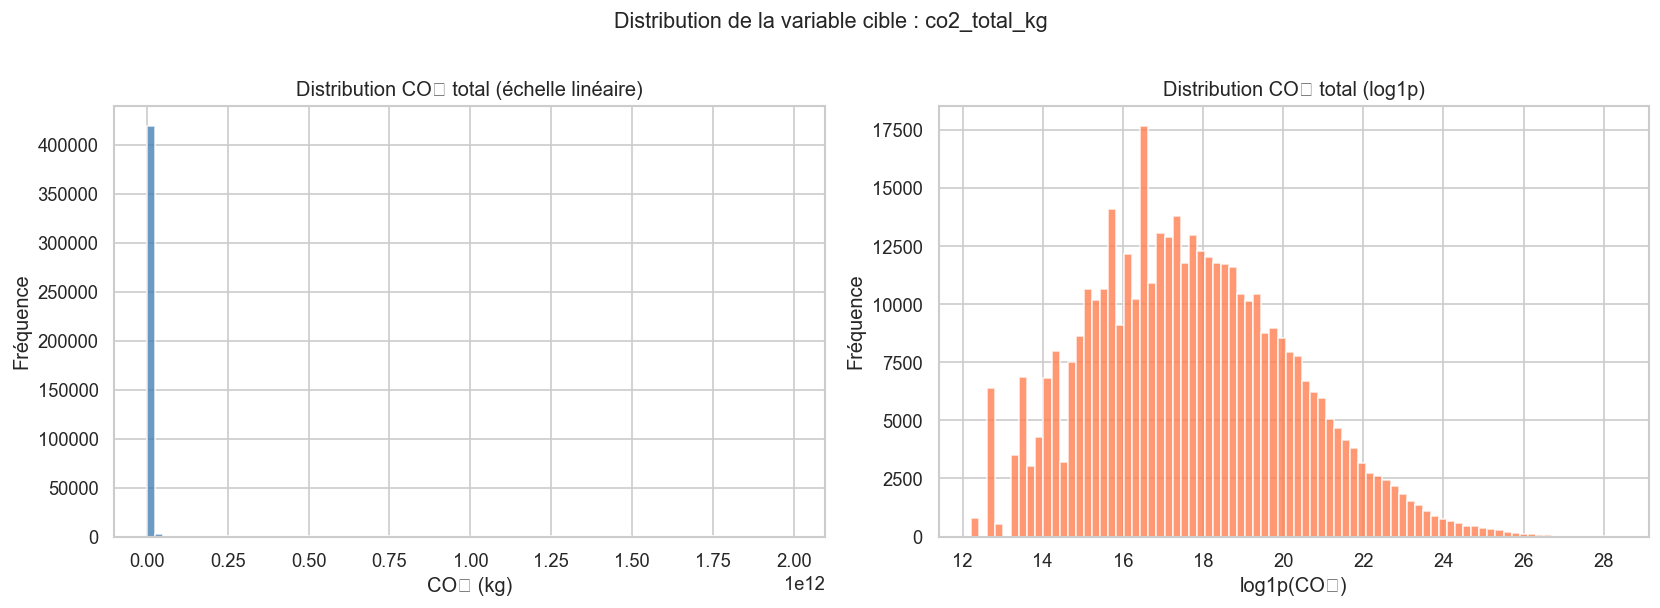

count              423,337
mean         1,803,552,341
std         24,897,174,711
min                200,000
25%              7,600,000
50%             42,300,000
75%            268,000,000
max      1,994,224,100,000
Name: co2_total_kg, dtype: object


In [4]:
# Distribution CO2 total (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['co2_total_kg'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution CO₂ total (échelle linéaire)')
axes[0].set_xlabel('CO₂ (kg)')
axes[0].set_ylabel('Fréquence')

log_co2 = np.log1p(df['co2_total_kg'].dropna())
axes[1].hist(log_co2, bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution CO₂ total (log1p)')
axes[1].set_xlabel('log1p(CO₂)')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Distribution de la variable cible : co2_total_kg', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(df['co2_total_kg'].describe().apply(lambda x: f'{x:,.0f}'))

C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\756868360.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Emeline\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


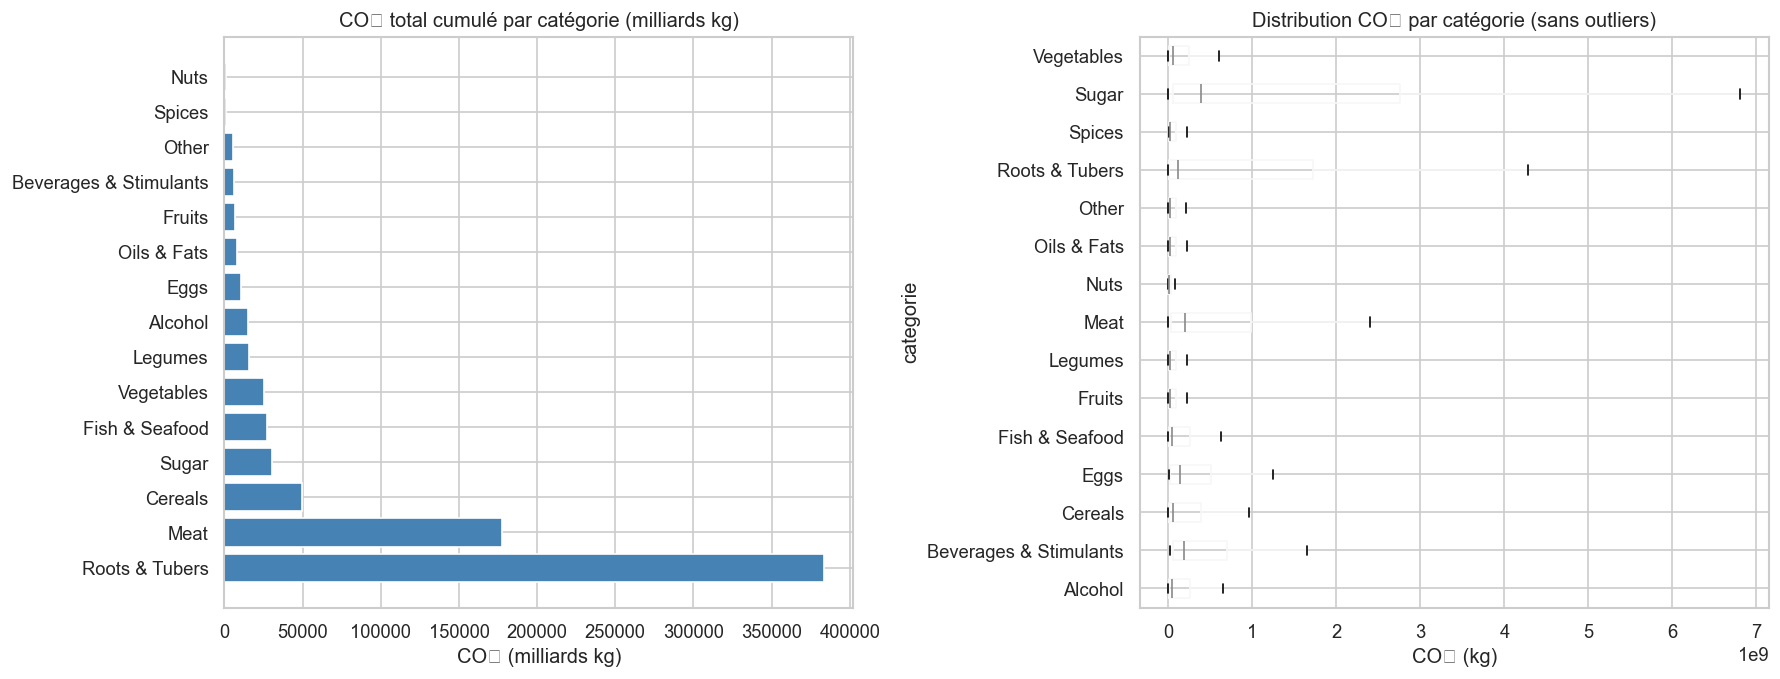

             categorie  co2_median    co2_total  n_obs
        Roots & Tubers 112200000.0 3.832082e+14  31485
                  Meat 198000000.0 1.774796e+14  69314
               Cereals  50400000.0 4.961185e+13  38661
                 Sugar 390000000.0 3.031993e+13   4298
        Fish & Seafood  40000000.0 2.726452e+13  25357
            Vegetables  49800000.0 2.521267e+13  38286
               Legumes  21600000.0 1.544679e+13  49209
               Alcohol  37800000.0 1.500109e+13  24811
                  Eggs 144000000.0 1.083002e+13   8857
           Oils & Fats  23400000.0 8.321860e+12  41766
                Fruits  17600000.0 6.859558e+12  33196
Beverages & Stimulants 181500000.0 6.315342e+12   7128
                 Other  20000000.0 5.645727e+12  33493
                Spices  24000000.0 1.256868e+12   6551
                  Nuts   6000000.0 7.364346e+11  10925


In [5]:
# CO2 médian par catégorie de produit
co2_cat = (
    df.groupby('categorie')['co2_total_kg']
    .agg(['median', 'sum', 'count'])
    .sort_values('sum', ascending=False)
    .reset_index()
)
co2_cat.columns = ['categorie', 'co2_median', 'co2_total', 'n_obs']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total CO2 par catégorie
axes[0].barh(co2_cat['categorie'], co2_cat['co2_total'] / 1e9, color='steelblue')
axes[0].set_title('CO₂ total cumulé par catégorie (milliards kg)')
axes[0].set_xlabel('CO₂ (milliards kg)')

# Médiane CO2 par catégorie (boxplot)
order = df.groupby('categorie')['co2_total_kg'].median().sort_values(ascending=False).index
df.boxplot(column='co2_total_kg', by='categorie', ax=axes[1],
           vert=False, showfliers=False)
axes[1].set_title('Distribution CO₂ par catégorie (sans outliers)')
axes[1].set_xlabel('CO₂ (kg)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(co2_cat.to_string(index=False))

In [6]:
# Top 20 pays par empreinte CO2 totale (toutes années)
co2_pays = (
    df.groupby(['iso3', 'nom_pays', 'region'])['co2_total_kg']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

fig = px.bar(
    co2_pays,
    x='co2_total_kg', y='nom_pays',
    color='region',
    orientation='h',
    title='Top 20 pays — Empreinte CO₂ cumulée (1961-2023)',
    labels={'co2_total_kg': 'CO₂ total (kg)', 'nom_pays': 'Pays'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=550)
fig.show()

C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\1733633720.py:10: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.

C:\Users\Emeline\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.



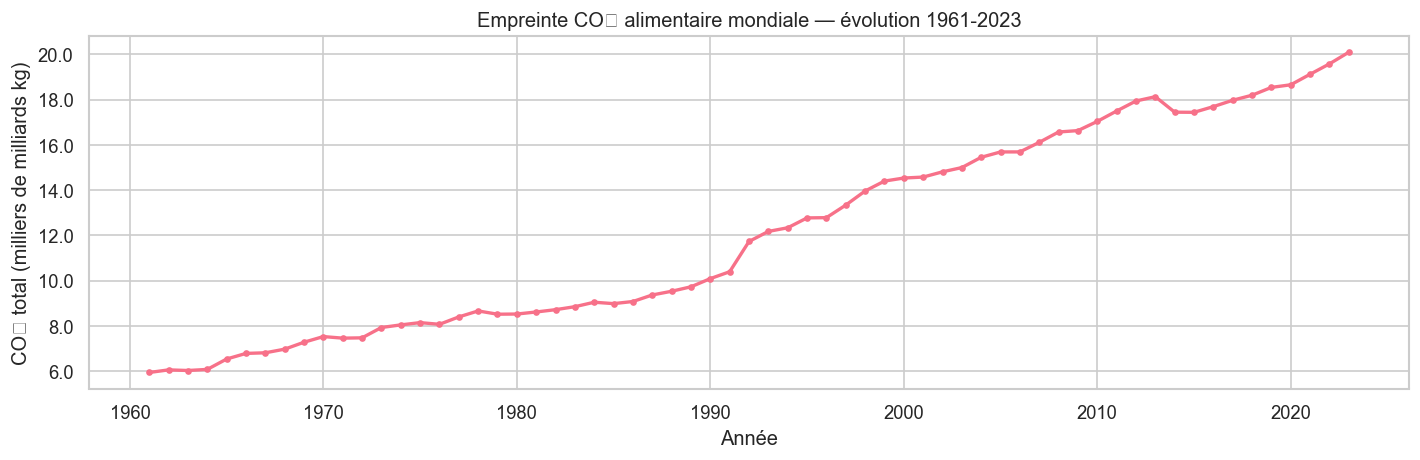

In [7]:
# Evolution temporelle CO2 total mondial
co2_year = df.groupby('annee')['co2_total_kg'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(co2_year['annee'], co2_year['co2_total_kg'] / 1e12, marker='o', markersize=3, linewidth=2)
ax.set_title('Empreinte CO₂ alimentaire mondiale — évolution 1961-2023')
ax.set_xlabel('Année')
ax.set_ylabel('CO₂ total (milliers de milliards kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
plt.tight_layout()
plt.show()

## 3.4 — Analyse bivariée

In [8]:
# Agrégation par pays × année (une ligne par pays/année)
df_agg = (
    df.groupby(['iso3', 'nom_pays', 'region', 'annee', 'pib_per_capita', 'taux_urbanisation', 'population', 'surface_agricole'])
    .agg(
        co2_total=('co2_total_kg', 'sum'),
        production_total=('quantite_1000t', 'sum')
    )
    .reset_index()
)

# CO2 per capita
df_agg['co2_per_capita'] = df_agg['co2_total'] / df_agg['population'].replace(0, np.nan)

# Filtrer les valeurs extrêmes et les NaN
df_biv = df_agg.dropna(subset=['pib_per_capita', 'co2_per_capita', 'taux_urbanisation'])
df_biv = df_biv[df_biv['co2_per_capita'] > 0]

print(f"Dataset agrégé : {len(df_agg):,} lignes pays×année")
print(f"Après filtrage NaN : {len(df_biv):,} lignes")

Dataset agrégé : 8,184 lignes pays×année
Après filtrage NaN : 8,184 lignes


In [9]:
# PIB vs CO2 per capita
fig = px.scatter(
    df_biv,
    x='pib_per_capita', y='co2_per_capita',
    color='region',
    size='population',
    hover_name='nom_pays',
    hover_data=['annee'],
    log_x=True, log_y=True,
    opacity=0.5,
    title='PIB/hab vs CO₂ alimentaire per capita (log-log)',
    labels={
        'pib_per_capita': 'PIB per capita (USD, log)',
        'co2_per_capita': 'CO₂ per capita (kg, log)'
    }
)
fig.show()

# Corrélations
r_pear, p_pear = stats.pearsonr(
    np.log1p(df_biv['pib_per_capita']),
    np.log1p(df_biv['co2_per_capita'])
)
r_spear, p_spear = stats.spearmanr(df_biv['pib_per_capita'], df_biv['co2_per_capita'])
print(f"Pearson (log-log) : r={r_pear:.3f}, p={p_pear:.2e}")
print(f"Spearman          : r={r_spear:.3f}, p={p_spear:.2e}")

Pearson (log-log) : r=0.334, p=1.41e-212
Spearman          : r=0.304, p=5.07e-174


In [10]:
# Urbanisation vs consommation de viande
df_viande = df[df['categorie'].str.lower().str.contains('meat|viand|animal', na=False)]

df_viande_agg = (
    df_viande.groupby(['iso3', 'nom_pays', 'region', 'annee', 'taux_urbanisation', 'population'])
    ['quantite_1000t'].sum().reset_index()
)
df_viande_agg['viande_per_capita_kg'] = (
    df_viande_agg['quantite_1000t'] * 1e6 / df_viande_agg['population'].replace(0, np.nan)
)
df_viande_biv = df_viande_agg.dropna(subset=['taux_urbanisation', 'viande_per_capita_kg'])
df_viande_biv = df_viande_biv[df_viande_biv['viande_per_capita_kg'] > 0]

fig = px.scatter(
    df_viande_biv,
    x='taux_urbanisation', y='viande_per_capita_kg',
    color='region',
    size='population',
    hover_name='nom_pays',
    hover_data=['annee'],
    opacity=0.5,
    title='Taux d\'urbanisation vs consommation de viande per capita',
    labels={
        'taux_urbanisation': 'Taux d\'urbanisation (%)',
        'viande_per_capita_kg': 'Viande per capita (kg/an)'
    }
)
fig.show()

r_spear2, p_spear2 = stats.spearmanr(
    df_viande_biv['taux_urbanisation'],
    df_viande_biv['viande_per_capita_kg']
)
print(f"Spearman urbanisation vs viande : r={r_spear2:.3f}, p={p_spear2:.2e}")

Spearman urbanisation vs viande : r=0.724, p=0.00e+00


C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\97162324.py:6: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.

C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\97162324.py:15: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.

C:\Users\Emeline\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.



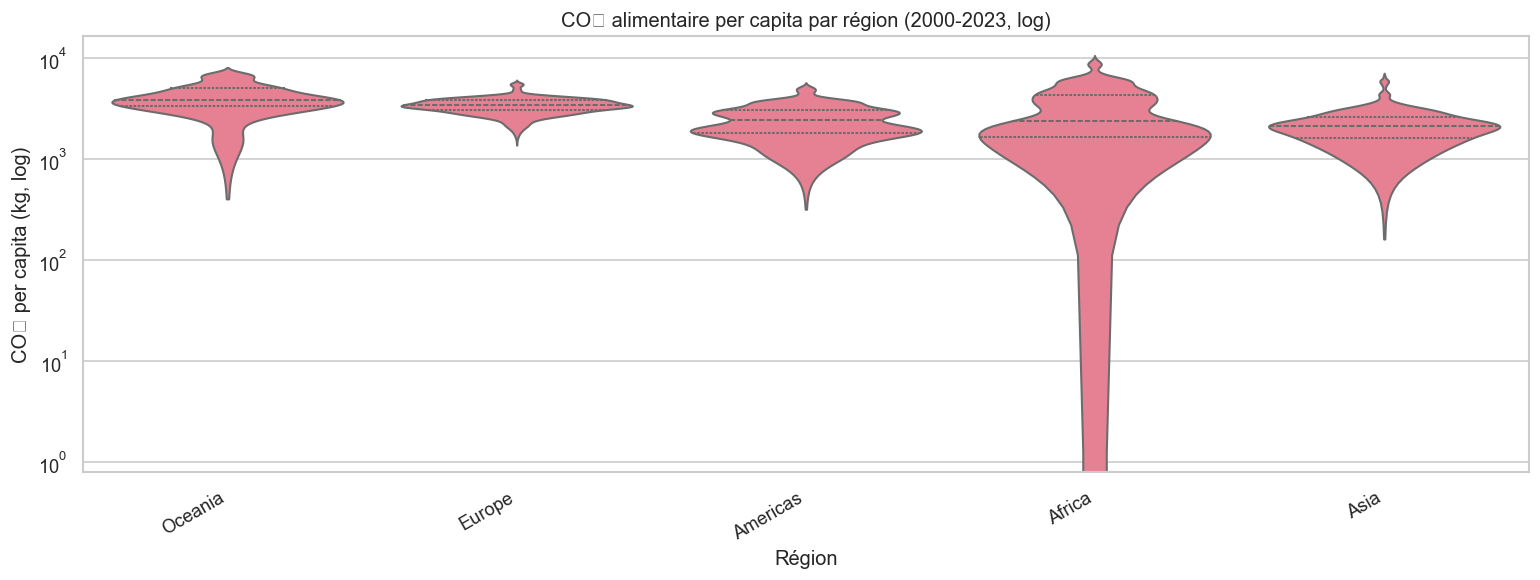

In [11]:
# CO2 per capita par région (violinplot)
df_region = df_biv[df_biv['annee'] >= 2000]  # focus période récente

fig, ax = plt.subplots(figsize=(13, 5))
order = df_region.groupby('region')['co2_per_capita'].median().sort_values(ascending=False).index
sns.violinplot(
    data=df_region, x='region', y='co2_per_capita',
    order=order, ax=ax, inner='quartile', scale='width'
)
ax.set_yscale('log')
ax.set_title('CO₂ alimentaire per capita par région (2000-2023, log)')
ax.set_xlabel('Région')
ax.set_ylabel('CO₂ per capita (kg, log)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3.5 — Analyse multivariée

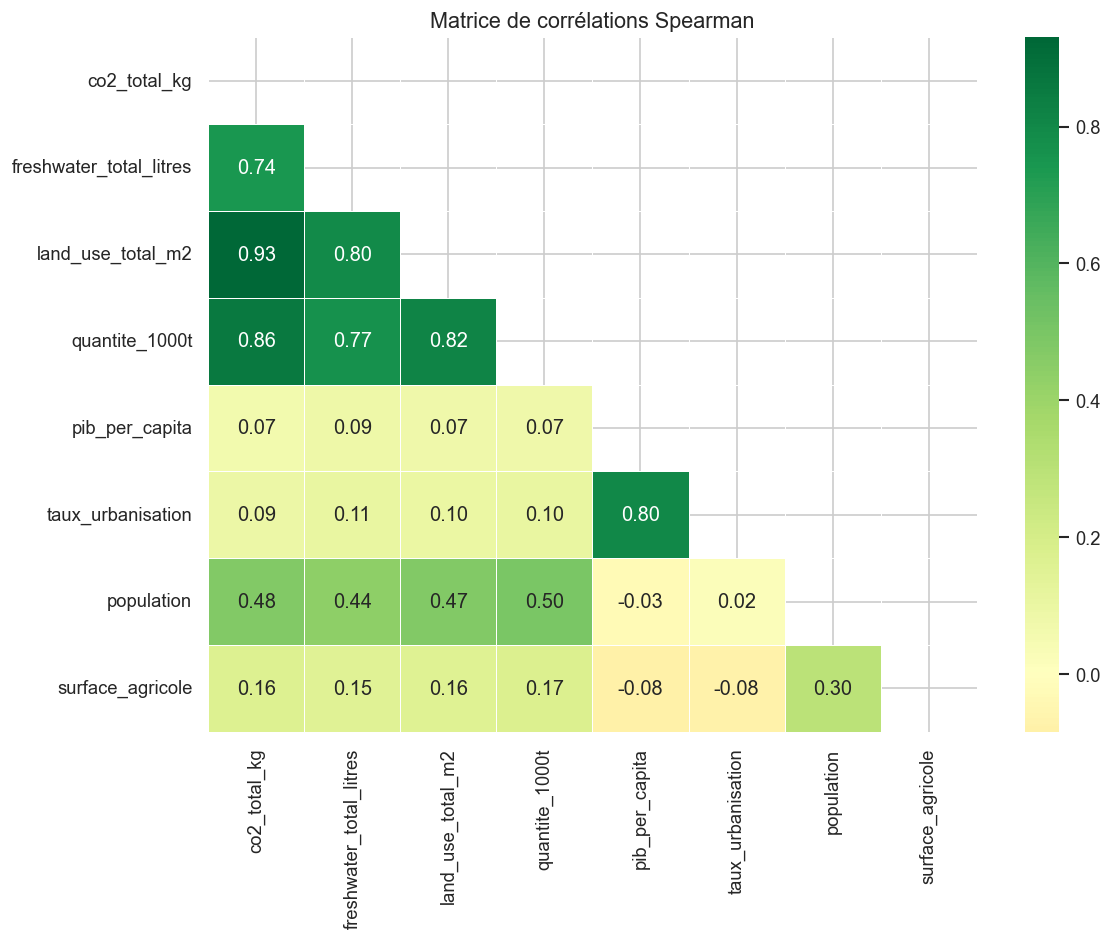

In [12]:
# Heatmap des corrélations
num_cols = [
    'co2_total_kg', 'freshwater_total_litres', 'land_use_total_m2',
    'quantite_1000t', 'pib_per_capita',
    'taux_urbanisation', 'population', 'surface_agricole'
]
df_corr = df[num_cols].dropna()

corr_matrix = df_corr.corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Matrice de corrélations Spearman', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# PCA sur les variables numériques agrégées par pays×année
pca_cols = ['co2_per_capita', 'pib_per_capita', 'taux_urbanisation', 'population', 'surface_agricole']
df_pca = df_biv[pca_cols + ['region', 'nom_pays', 'annee']].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[pca_cols])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df_pca = df_pca.copy()
df_pca['PC1'] = coords[:, 0]
df_pca['PC2'] = coords[:, 1]

print(f"Variance expliquée : PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total : {pca.explained_variance_ratio_.sum():.1%}")

fig = px.scatter(
    df_pca,
    x='PC1', y='PC2',
    color='region',
    hover_name='nom_pays',
    hover_data=['annee'],
    opacity=0.5,
    title=f'PCA — Pays×Année (PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%})',
)
fig.show()

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)
print("\nLoadings PCA :")
print(loadings.to_string())

Variance expliquée : PC1=31.9%, PC2=22.1%
Total : 54.0%



Loadings PCA :
                        PC1       PC2
pib_per_capita     0.663277  0.121443
taux_urbanisation  0.651975  0.124467
co2_per_capita     0.310467  0.097699
surface_agricole  -0.131251  0.705120
population        -0.146203  0.680455


## 3.6 — Tests statistiques & hypothèses

In [14]:
# ANOVA : différence d'empreinte CO2 per capita entre régions
df_ano = df_biv.dropna(subset=['co2_per_capita', 'region'])
groups = [g['co2_per_capita'].values for _, g in df_ano.groupby('region')]

f_stat, p_anova = stats.f_oneway(*groups)
print("=== ANOVA : CO₂ per capita ~ Région ===")
print(f"F={f_stat:.2f}, p={p_anova:.2e}")
if p_anova < 0.05:
    print("→ Différences significatives entre régions (p < 0.05)")
else:
    print("→ Pas de différence significative entre régions")

# Kruskal-Wallis (non-paramétrique, plus robuste)
h_stat, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis : H={h_stat:.2f}, p={p_kw:.2e}")

# Médiane par région
print("\nCO₂ per capita médian par région :")
print(
    df_ano.groupby('region')['co2_per_capita']
    .median()
    .sort_values(ascending=False)
    .apply(lambda x: f'{x:,.0f} kg')
    .to_string()
)

=== ANOVA : CO₂ per capita ~ Région ===
F=488.90, p=0.00e+00
→ Différences significatives entre régions (p < 0.05)

Kruskal-Wallis : H=1979.87, p=0.00e+00

CO₂ per capita médian par région :
region
Oceania     3,703 kg
Europe      3,401 kg
Africa      2,248 kg
Americas    2,140 kg
Asia        1,785 kg


Rows animal : 92,943 / 383,012


C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\2350127838.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\2350127838.py:42: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.

C:\Users\Emeline\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.



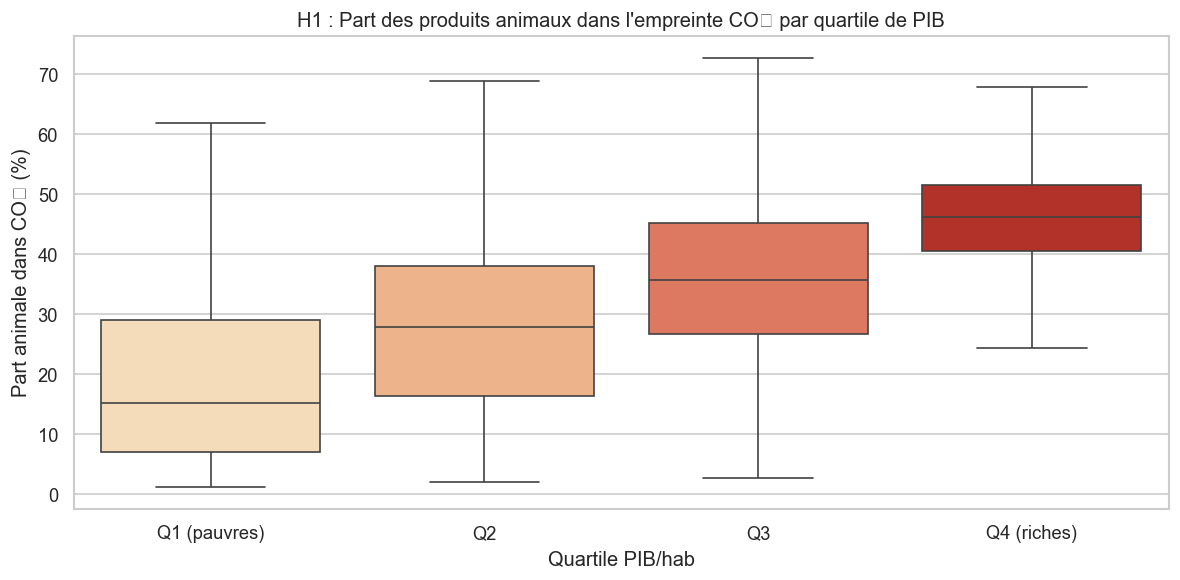

Médiane part animale par quartile :
quartile_pib
Q1 (pauvres)    15.3
Q2              27.8
Q3              35.6
Q4 (riches)     46.3
Name: pct_animal, dtype: float64

Kruskal-Wallis (H1) : H=3163.41, p=0.00e+00
→ H1 VALIDÉE


In [15]:
# H1 : Pays riches → empreinte animale plus forte

# Catégories animales telles que définies dans dim_produits
# Note : 'Dairy' absent des données, on garde Meat/Eggs/Fish & Seafood
ANIMAL_CATS = ['Meat', 'Dairy', 'Eggs', 'Fish & Seafood']

df_h1 = df.dropna(subset=['pib_per_capita']).copy()
df_h1['quartile_pib'] = pd.qcut(
    df_h1['pib_per_capita'], 4,
    labels=['Q1 (pauvres)', 'Q2', 'Q3', 'Q4 (riches)']
)
df_h1['is_animal'] = df_h1['categorie'].isin(ANIMAL_CATS)

print(f"Rows animal : {df_h1['is_animal'].sum():,} / {len(df_h1):,}")

# Agrégation : CO2 animal et CO2 total par pays×année×quartile
# observed=True : on ne génère que les combinaisons présentes dans les données
# (sans ça, pandas crée des lignes fantômes à 0 pour chaque quartile × pays,
#  ce qui noie les vraies valeurs et fait tomber toutes les médianes à 0)
co2_animal = (
    df_h1[df_h1['is_animal']]
    .groupby(['iso3', 'annee', 'quartile_pib'], observed=True)['co2_total_kg']
    .sum().reset_index().rename(columns={'co2_total_kg': 'co2_animal'})
)
co2_total = (
    df_h1.groupby(['iso3', 'annee', 'quartile_pib'], observed=True)['co2_total_kg']
    .sum().reset_index().rename(columns={'co2_total_kg': 'co2_total'})
)
co2_quartile = co2_total.merge(co2_animal, on=['iso3', 'annee', 'quartile_pib'], how='left')
co2_quartile['co2_animal'] = co2_quartile['co2_animal'].fillna(0)
co2_quartile['pct_animal'] = co2_quartile['co2_animal'] / (co2_quartile['co2_total'] + 1e-10) * 100

order = ['Q1 (pauvres)', 'Q2', 'Q3', 'Q4 (riches)']
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=co2_quartile, x='quartile_pib', y='pct_animal',
    order=order, ax=ax, palette='OrRd', showfliers=False
)
ax.set_title('H1 : Part des produits animaux dans l\'empreinte CO₂ par quartile de PIB')
ax.set_xlabel('Quartile PIB/hab')
ax.set_ylabel('Part animale dans CO₂ (%)')
plt.tight_layout()
plt.show()

print("Médiane part animale par quartile :")
print(co2_quartile.groupby('quartile_pib', observed=True)['pct_animal'].median().reindex(order).round(1))

groups_pib = [g['pct_animal'].values for _, g in co2_quartile.groupby('quartile_pib', observed=True)]
h2, p2 = stats.kruskal(*groups_pib)
print(f"\nKruskal-Wallis (H1) : H={h2:.2f}, p={p2:.2e}")
print("→ H1 VALIDÉE" if p2 < 0.05 else "→ H1 non validée")

C:\Users\Emeline\AppData\Local\Temp\ipykernel_6312\1421277578.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




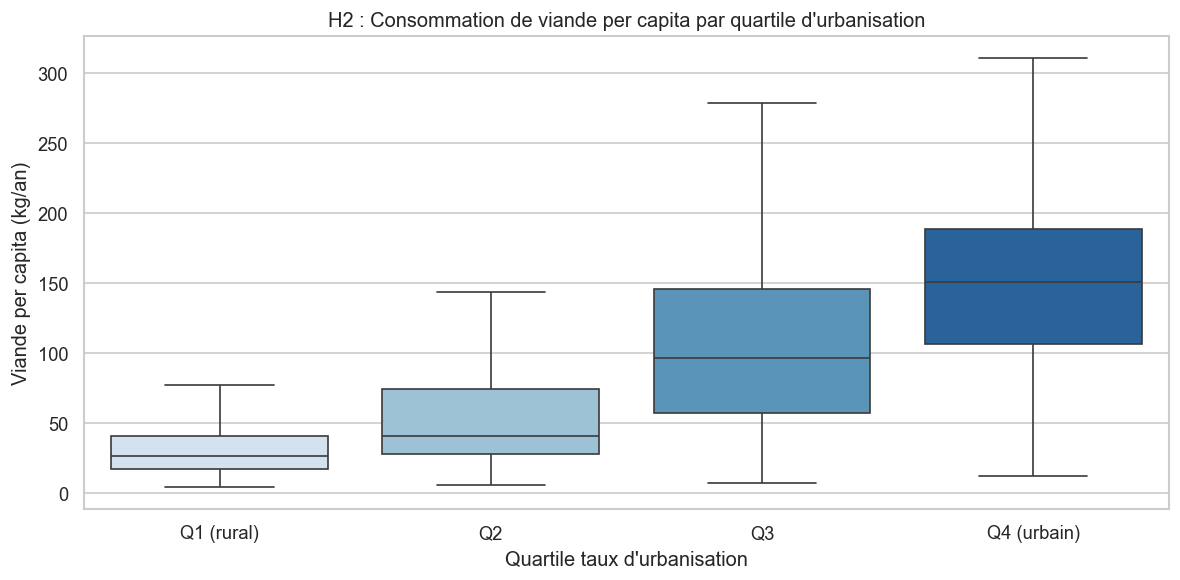

Médiane viande per capita par quartile d'urbanisation :
quartile_urba
Q1 (rural)      26.46
Q2              40.37
Q3              96.23
Q4 (urbain)    150.48
Name: viande_per_capita_kg, dtype: float64

Kruskal-Wallis (H2) : H=4386.77, p=0.00e+00
→ H2 VALIDÉE


In [16]:
# H2 : Urbanisation ↑ → consommation viande ↑
# (déjà visualisé en 3.4, on formalise ici le test)
df_h2 = df_viande_biv.copy()
df_h2 = df_h2.assign(
    quartile_urba=pd.qcut(df_h2['taux_urbanisation'], 4,
                          labels=['Q1 (rural)', 'Q2', 'Q3', 'Q4 (urbain)'])
)

fig, ax = plt.subplots(figsize=(10, 5))
order = ['Q1 (rural)', 'Q2', 'Q3', 'Q4 (urbain)']
sns.boxplot(
    data=df_h2, x='quartile_urba', y='viande_per_capita_kg',
    order=order, ax=ax, palette='Blues', showfliers=False
)
ax.set_title('H2 : Consommation de viande per capita par quartile d\'urbanisation')
ax.set_xlabel('Quartile taux d\'urbanisation')
ax.set_ylabel('Viande per capita (kg/an)')
plt.tight_layout()
plt.show()

print("Médiane viande per capita par quartile d'urbanisation :")
print(df_h2.groupby('quartile_urba', observed=True)['viande_per_capita_kg'].median().reindex(order).round(2))

groups_urba = [g['viande_per_capita_kg'].values for _, g in df_h2.groupby('quartile_urba', observed=True)]
h3, p3 = stats.kruskal(*groups_urba)
print(f"\nKruskal-Wallis (H2) : H={h3:.2f}, p={p3:.2e}")
print("→ H2 VALIDÉE" if p3 < 0.05 else "→ H2 non validée")

## 3.7 — Carte mondiale (bonus)

In [17]:
# Choropleth CO2 per capita — moyenne sur 2010-2023
df_map = (
    df_biv[df_biv['annee'] >= 2010]
    .groupby(['iso3', 'nom_pays'])
    ['co2_per_capita'].mean()
    .reset_index()
)

fig = px.choropleth(
    df_map,
    locations='iso3',
    color='co2_per_capita',
    hover_name='nom_pays',
    color_continuous_scale='YlOrRd',
    title='Empreinte CO₂ alimentaire per capita — moyenne 2010-2023 (kg)',
    labels={'co2_per_capita': 'CO₂/hab (kg)'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

## 3.8 — Conclusions & variables pour le ML

In [18]:
# Résumé des corrélations Spearman avec co2_total_kg
features_ml = ['quantite_1000t', 'pib_per_capita', 'taux_urbanisation', 'population', 'surface_agricole']
df_corr_summary = df[features_ml + ['co2_total_kg']].dropna()

print("=== Corrélations Spearman avec co2_total_kg ===")
for col in features_ml:
    r, p = stats.spearmanr(df_corr_summary[col], df_corr_summary['co2_total_kg'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"  {col:<30} r={r:+.3f}  p={p:.2e}  {sig}")

=== Corrélations Spearman avec co2_total_kg ===
  quantite_1000t                 r=+0.867  p=0.00e+00  ***
  pib_per_capita                 r=+0.054  p=2.33e-244  ***
  taux_urbanisation              r=+0.080  p=0.00e+00  ***
  population                     r=+0.474  p=0.00e+00  ***
  surface_agricole               r=+0.158  p=0.00e+00  ***


### Synthèse EDA

**Distribution de la cible (`co2_total_kg`) :**
- 423 337 observations (pays × année × produit), médiane 42,3 M kg, max 1 994 Mds kg
- Distribution très asymétrique (log-normale) → transformer en `log1p(co2_total_kg)` pour le ML ou utiliser des modèles robustes (RandomForest, XGBoost)

**Catégories les plus émissives (CO₂ total cumulé) :**
| Catégorie | CO₂ total cumulé | Médiane par obs |
|-----------|-----------------|-----------------|
| Roots & Tubers | 383 Billions kg (1er) | 112 M kg |
| Meat | 177 Billions kg (2e) | 198 M kg |
| Cereals | 49,6 Billions kg | 50 M kg |
| Sugar | 30,3 Billions kg | 390 M kg (**médiane la plus élevée**) |
| Fish & Seafood | 27,3 Billions kg | 40 M kg |

→ La viande a la 2e empreinte cumulée mais le sucre le facteur d'émission médian le plus fort par observation.

**Différences régionales (CO₂ alimentaire per capita, 2000-2023) :**
| Région | Médiane |
|--------|---------|
| Oceania | 3 703 kg/hab |
| Europe | 3 401 kg/hab |
| Africa | 2 248 kg/hab |
| Americas | 2 140 kg/hab |
| Asia | 1 785 kg/hab |

→ ANOVA et Kruskal-Wallis confirment des différences hautement significatives entre régions (F=488.90, H=1979.87, p≈0).

**Hypothèses :**

- **H1 (PIB → empreinte animale) : VALIDÉE** — Kruskal-Wallis H=3163, p≈0
  | Quartile PIB | Part animale médiane dans CO₂ |
  |---|---|
  | Q1 (pauvres) | 15,3 % |
  | Q2 | 27,8 % |
  | Q3 | 35,6 % |
  | Q4 (riches) | 46,3 % |

- **H2 (Urbanisation → consommation viande) : VALIDÉE** — Kruskal-Wallis H=4387, p≈0, Spearman r=0.724
  | Quartile urbanisation | Viande médiane per capita |
  |---|---|
  | Q1 (rural) | 26,5 kg/an |
  | Q2 | 40,4 kg/an |
  | Q3 | 96,2 kg/an |
  | Q4 (urbain) | 150,5 kg/an |

**Corrélations Spearman avec `co2_total_kg` (niveau produit) :**
| Feature | r Spearman | Significativité |
|---------|-----------|-----------------|
| `quantite_1000t` | +0.867 | *** très forte |
| `population` | +0.474 | *** modérée |
| `surface_agricole` | +0.158 | *** faible |
| `taux_urbanisation` | +0.080 | *** faible |
| `pib_per_capita` | +0.054 | *** faible |

Note : PIB et urbanisation ont une corrélation faible avec `co2_total_kg` au niveau produit, mais forte avec `co2_per_capita` au niveau pays (Spearman r=0.304 et r=0.724) — ce sont des variables à intégrer dans le ML via l'agrégation pays×année.

**PCA (5 variables, niveau pays×année) :**
- PC1 (31,9 %) capte l'axe **richesse + urbanisation** (loadings : PIB 0.66, urbanisation 0.65)
- PC2 (22,1 %) capte l'axe **taille du pays** (population 0.68, surface agricole 0.71)
- Total variance expliquée : 54,0 % sur 2 composantes

**Variables retenues pour le ML (Étape 4) :**
| Feature | Type | Justification |
|---------|------|---------------|
| `quantite_1000t` | numérique | Corrélation directe avec CO₂ (r=0.867) |
| `categorie` | catégorielle | Facteur d'émission varie fortement entre catégories |
| `pib_per_capita` | numérique | Détermine la part animale (H1 validée) |
| `taux_urbanisation` | numérique | Lié à la consommation de viande (H2, r=0.724) |
| `population` | numérique | Corrélation modérée (r=0.474) |
| `surface_agricole` | numérique | Contexte productif (r=0.158) |
| `region` | catégorielle | Différences significatives entre régions confirmées |